In [43]:
import time
from time import sleep, monotonic
import datetime
import numpy as np
import matplotlib.pyplot as plt
import sys
import pyvisa
import qcodes as qc
from qcodes.dataset import Measurement
from qcodes.dataset import do0d
from qcodes.dataset.experiment_container import new_experiment, load_experiment_by_name
from qcodes.dataset.plotting import plot_by_id
from qcodes.dataset.data_set import load_by_id, load_by_counter
from qcodes import initialise_or_create_database_at, new_data_set, new_experiment
from qcodes.station import Station
from ipywidgets import interact, IntSlider
initialise_or_create_database_at("./2026-05-11_SNSPD12.db")
import snspd
params = snspd.snspd('snspd12.yaml')
from scipy.signal import find_peaks
import numpy as np

# Set up experiment
exp_name = 'SNSPD12_29_05_2026'
sample_name = '00'

try:
    exp = qc.load_experiment_by_name(exp_name, sample=sample_name)
    print('Experiment loaded. Last ID no:', exp.last_counter)
except ValueError:
    exp = new_experiment(exp_name, sample_name)
    print('Started new experiment')

Experiment loaded. Last ID no: 317


In [2]:
import importlib
importlib.reload(snspd)
params = snspd.snspd('snspd12.yaml')

In [3]:
import pandas as pd

def generate_dataframe(IDrange):
    data_dict = {}
    for ID in IDrange: 
        data = load_by_id(ID).get_parameter_data()
        trace = data['trace']['trace']
        taxis = data['trace']['time_axis']
        current = data['yoko_current']['yoko_current'][0]
        trigger = data['trigger']['trigger'][0]
        peaks, properties = find_peaks(trace, height=float(trigger), distance=len(trace))
        key = f'{current*1e6:.2f}'

        peak_voltage = None if len(peaks)<1 else trace[peaks][0]
        
        try: 
            v_scale = data['v_scale']['v_scale'][0]
        except KeyError: 
            v_scale = None
        try: 
            data_dict[key]
            print(f'duplicate current {key} ID {ID}')
        except: 
            data_dict[key] = {'current': current, 
                            'trigger': trigger,
                             'v_scale': v_scale,
                            'peak_voltage': peak_voltage,
                              'ID': int(ID),
                             }
    return pd.DataFrame(data=data_dict)


In [44]:
# get peak 
from scipy.signal import find_peaks
import numpy as np

def plot_traces(ID):
    data = load_by_id(ID).get_parameter_data()
    trace = data['trace']['trace']
    taxis = data['trace']['time_axis']
    current = data['yoko_current']['yoko_current']
    trigger = data['trigger']['trigger'][0]
    plt.plot(taxis, trace)
    peaks, properties = find_peaks(trace, height=float(trigger), distance=len(trace))
    plt.plot(taxis, np.ones_like(taxis)*float(trigger), label=f'Trigger in sweep {trigger*1e3}mV')
    plt.plot(taxis[peaks],trace[peaks], 'ro', label='Peak')
    plt.title(f'ID: {ID} Current: {current[0]*1e6}uA')
    plt.legend()
    # plt.ylabel('Voltage (V)')
    # plt.xlabel('Time (s)')
    print(current, trace[peaks], 0.8*trace[peaks], 0.5*trace[peaks])
    print(f'Peak voltage: {trace[peaks]}')

interact(plot_traces, ID=IntSlider(min=121, max=173, step=1, value=121,
                                  continuous_update=False));

interactive(children=(IntSlider(value=121, continuous_update=False, description='ID', max=173, min=121), Outpu…

In [104]:
dataframe['-6.25']

current          -0.000006
trigger           0.102000
v_scale                NaN
peak_voltage      0.138000
ID              146.000000
Name: -6.25, dtype: float64

In [94]:
len(peaks)

0

In [45]:
# get peak 
from scipy.signal import find_peaks
import numpy as np

def plot_traces(ID):
    data = load_by_id(ID).get_parameter_data()
    trace = data['trace']['trace']
    taxis = data['trace']['time_axis']
    current = data['yoko_current']['yoko_current']
    trigger = data['trigger']['trigger'][0]
    plt.plot(taxis, trace)
    peaks, properties = find_peaks(trace, height=float(trigger), distance=len(trace))
    plt.plot(taxis, np.ones_like(taxis)*float(trigger), label=f'Trigger in sweep {trigger*1e3}mV')
    plt.plot(taxis[peaks],trace[peaks], 'ro', label='Peak')
    plt.title(f'ID: {ID} Current: {current[0]*1e6}uA')
    plt.legend()
    # plt.ylabel('Voltage (V)')
    # plt.xlabel('Time (s)')
    print(current, trace[peaks], 0.8*trace[peaks], 0.2*trace[peaks])
    print(f'Peak voltage: {trace[peaks]}')

interact(plot_traces, ID=IntSlider(min=177, max=230, step=1, value=121,
                                  continuous_update=False));

interactive(children=(IntSlider(value=177, continuous_update=False, description='ID', max=230, min=177), Outpu…

In [46]:
# get peak 
from scipy.signal import find_peaks
import numpy as np

def plot_traces(ID):
    data = load_by_id(ID).get_parameter_data()
    trace = data['trace']['trace']
    taxis = data['trace']['time_axis']
    current = data['yoko_current']['yoko_current']
    trigger = data['trigger']['trigger'][0]
    plt.plot(taxis, trace)
    peaks, properties = find_peaks(trace, height=float(trigger), distance=len(trace))
    plt.plot(taxis, np.ones_like(taxis)*float(trigger), label=f'Trigger in sweep {trigger*1e3}mV')
    plt.plot(taxis[peaks],trace[peaks], 'ro', label='Peak')
    plt.title(f'ID: {ID} Current: {current[0]*1e6}uA')
    plt.legend()
    # plt.ylabel('Voltage (V)')
    # plt.xlabel('Time (s)')
    print(current, trace[peaks], 0.8*trace[peaks], 0.2*trace[peaks])
    print(f'Peak voltage: {trace[peaks]}')

interact(plot_traces, ID=IntSlider(min=261, max=271, step=1, value=261,
                                  continuous_update=False));

interactive(children=(IntSlider(value=261, continuous_update=False, description='ID', max=271, min=261), Outpu…

Peak from ID 261 ad current -2.5uA luckily randomly caught a peak! A trigger near 0.01 will clear the overshoot. 0.006*2 = 0.012 

In [47]:
# get peak 
from scipy.signal import find_peaks
import numpy as np

def plot_traces(ID):
    data = load_by_id(ID).get_parameter_data()
    trace = data['trace']['trace']
    taxis = data['trace']['time_axis']
    current = data['yoko_current']['yoko_current']
    trigger = data['trigger']['trigger'][0]
    plt.plot(taxis, trace)
    peaks, properties = find_peaks(trace, height=float(trigger), distance=len(trace))
    plt.plot(taxis, np.ones_like(taxis)*float(trigger), label=f'Trigger in sweep {trigger*1e3}mV')
    plt.plot(taxis[peaks],trace[peaks], 'ro', label='Peak')
    plt.title(f'ID: {ID} Current: {current[0]*1e6}uA')
    plt.legend()
    # plt.ylabel('Voltage (V)')
    # plt.xlabel('Time (s)')
    print(current, trace[peaks], 0.8*trace[peaks], 0.2*trace[peaks])
    print(f'Peak voltage: {trace[peaks]}')

interact(plot_traces, ID=IntSlider(min=280, max=290, step=1, value=280,
                                  continuous_update=False));

interactive(children=(IntSlider(value=280, continuous_update=False, description='ID', max=290, min=280), Outpu…

In [13]:
curr = 9e-6

In [16]:
f'{curr:.2e}'

'9.00e-06'

In [5]:
range1 = np.arange(121, 173)
range2 = np.arange(261, 272)
range3 = np.arange(280, 291)

data = generate_dataframe(np.concatenate([range3, range2, range1]))

duplicate current -2.50 ID 261
duplicate current 0.00 ID 121
duplicate current -0.25 ID 122
duplicate current -0.50 ID 123
duplicate current -0.75 ID 124
duplicate current -1.00 ID 125
duplicate current -1.25 ID 126
duplicate current -1.50 ID 127
duplicate current -1.75 ID 128
duplicate current -2.00 ID 129
duplicate current -2.25 ID 130
duplicate current -2.50 ID 131
duplicate current -2.75 ID 132
duplicate current -3.00 ID 133
duplicate current -3.25 ID 134
duplicate current -3.50 ID 135
duplicate current -3.75 ID 136
duplicate current -4.00 ID 137
duplicate current -4.25 ID 138
duplicate current -4.50 ID 139
duplicate current -4.75 ID 140
duplicate current -5.00 ID 141


In [15]:
range1 = np.arange(121, 173)
range2 = np.arange(261, 272)
range3 = np.arange(280, 291)

data = generate_dataframe(np.concatenate([range3, range2, range1]))


duplicate current -2.50 ID 261
duplicate current 0.00 ID 121
duplicate current -0.25 ID 122
duplicate current -0.50 ID 123
duplicate current -0.75 ID 124
duplicate current -1.00 ID 125
duplicate current -1.25 ID 126
duplicate current -1.50 ID 127
duplicate current -1.75 ID 128
duplicate current -2.00 ID 129
duplicate current -2.25 ID 130
duplicate current -2.50 ID 131
duplicate current -2.75 ID 132
duplicate current -3.00 ID 133
duplicate current -3.25 ID 134
duplicate current -3.50 ID 135
duplicate current -3.75 ID 136
duplicate current -4.00 ID 137
duplicate current -4.25 ID 138
duplicate current -4.50 ID 139
duplicate current -4.75 ID 140
duplicate current -5.00 ID 141


In [16]:
data

,0.00,-0.25,-0.50,-0.75,-1.00,-1.25,-1.50,-1.75,-2.00,-2.25,...,-10.50,-10.75,-11.00,-11.25,-11.50,-11.75,-12.00,-12.25,-12.50,-12.75
current,0.000,-2.500000e-07,-5.000000e-07,-7.500000e-07,-0.000001,-0.000001,-0.000002,-0.000002,-0.000002,-0.000002,...,-0.00001,-0.000011,-0.000011,-0.000011,-0.000012,-0.000012,-0.000012,-0.000012,-0.000013,-0.000013
trigger,0.012,1.200000e-02,1.200000e-02,1.200000e-02,0.012000,0.012000,0.012000,0.012000,0.012000,0.012000,...,0.10200,0.102000,0.102000,0.102000,0.102000,0.102000,0.102000,0.102000,0.102000,0.102000
v_scale,0.150,1.500000e-01,1.500000e-01,1.500000e-01,0.150000,0.150000,0.150000,0.150000,0.150000,0.150000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
peak_voltage,NaN,NaN,1.200000e-02,NaN,NaN,NaN,NaN,0.024000,0.030000,0.036000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ID,280.000,2.810000e+02,2.820000e+02,2.830000e+02,284.000000,285.000000,286.000000,287.000000,288.000000,289.000000,...,163.00000,164.000000,165.000000,166.000000,167.000000,168.000000,169.000000,170.000000,171.000000,172.000000


In [42]:
from ipywidgets import fixed
def plot_traces(idx, IDs):
    ID = IDs[idx]
    data = load_by_id(ID).get_parameter_data()
    trace = data['trace']['trace']
    taxis = data['trace']['time_axis']
    current = data['yoko_current']['yoko_current']
    trigger = data['trigger']['trigger'][0]
    plt.plot(taxis, trace)
    peaks, properties = find_peaks(trace, height=float(trigger), distance=len(trace))
    plt.plot(taxis, np.ones_like(taxis)*float(trigger), label=f'Trigger in sweep {trigger*1e3}mV')
    
    peak_voltage = 0 if len(peaks)<1 else trace[peaks][0]
    # set v_scale to half the peak height
    v_scale = peak_voltage/2
    threshold1 = 0.8*peak_voltage
    threshold2 = 0.3*peak_voltage
    plt.plot(taxis, np.ones_like(taxis)*threshold1, label=f'Threshold1 80%')
    plt.plot(taxis, np.ones_like(taxis)*threshold2, label=f'Threshold2 30% {threshold2}')
    plt.plot(taxis[peaks],trace[peaks], 'ro', label='Peak')
    plt.title(f'ID: {ID} Current: {current[0]*1e6}uA')
    plt.legend()
    # plt.ylabel('Voltage (V)')
    # plt.xlabel('Time (s)')
    print(current, trace[peaks], 0.8*trace[peaks], 0.2*trace[peaks])
    print(f'Peak voltage: {trace[peaks]}')

IDs = [int(i) for i in list(data.loc['ID'])]
interact(plot_traces, idx=IntSlider(min=0, max=len(IDs), step=1, value=0,
                                  continuous_update=False), IDs=fixed(IDs));

interactive(children=(IntSlider(value=0, continuous_update=False, description='idx', max=52), Output()), _dom_…

(-2e-07, 0.0)

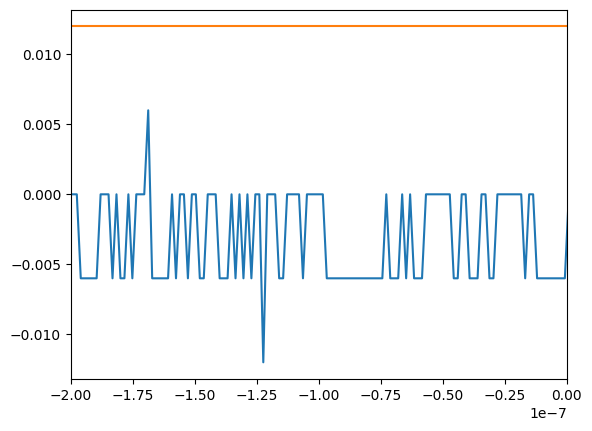

In [50]:
data = load_by_id(286).get_parameter_data()
trace = data['trace']['trace']
taxis = data['trace']['time_axis']
current = data['yoko_current']['yoko_current']
trigger = data['trigger']['trigger'][0]
plt.plot(taxis, trace)
peaks, properties = find_peaks(trace, height=float(trigger), distance=len(trace))
plt.plot(taxis, np.ones_like(taxis)*float(trigger), label=f'Trigger in sweep {trigger*1e3}mV')
plt.xlim([-0.2e-6, 0])

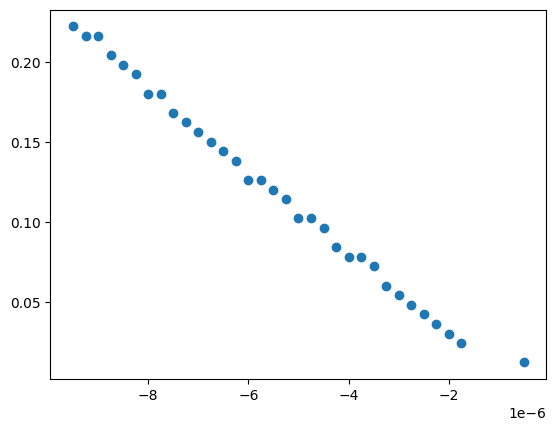

In [31]:
plt.plot(list(data.loc['current']), list(data.loc['peak_voltage']), 'o')
# R = -100 
# V = [i*R for i in data.loc['current']]
# plt.plot(list(data.loc['current']), V, 'o')

In [ ]:
yoko.current()